In [1]:
from binance.client import Client as bnb_client
from datetime import datetime
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path

import cvxpy as cvx
from sklearn.covariance import LedoitWolf

Data sourcing 
=====
In order to take advantage of diversification, we include a list of cryptocurrencies with >$1bn market cap in our study

In [2]:
import requests

cg = requests.get(
    "https://api.coingecko.com/api/v3/coins/markets",
    params={
        "vs_currency": "usd",
        "order": "market_cap_desc",
        "per_page": 100,
        "page": 1
    }
).json()

large_caps = {c["symbol"].upper() for c in cg if c["market_cap"] > 1_000_000_000}

url = "https://api.binance.com/api/v3/exchangeInfo"
data = requests.get(url, timeout=10).json()

symbols = [
    s["symbol"]
    for s in data["symbols"]
    if s["quoteAsset"] == "USDT" and s["status"] == "TRADING" and s["baseAsset"] in large_caps
]
print(f'Number of crypto symbols considered: {len(symbols)}')

Number of crypto symbols considered: 40


In [3]:
client = bnb_client()
###  if you're in the US, use: 
### "client = bnb_client(tld='US')" here instead

def get_binance_px(symbol,freq,start_ts = '2020-01-01'):
    data = client.get_historical_klines(symbol,freq,start_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp to UTC
    data['open_time'] = pd.to_datetime(data['open_time'], unit='ms', utc=True)
    data['close_time'] = pd.to_datetime(data['close_time'], unit='ms', utc=True)

    non_float_types = ['open_time', 'close_time', 'ignore']
    cols = data.columns.difference(non_float_types)
    data[cols] = data[cols].astype(float)
    data['symbol'] = symbol
    
    return data 

# using daily interval data starting from 2020
f, interval, mult = 1, 'd', 365
freq = f'{f}{interval}'
file_name = f'crypto_{freq}.pk'
reload = False
if not reload and Path(file_name).exists():
    data = pd.read_pickle(file_name)
else:
    data = [ get_binance_px(x,freq, '2020-01-01') for x in symbols ]
    data = pd.concat(data, axis=0)
    data = data.set_index(['open_time','close_time','symbol']).unstack('symbol').swaplevel(axis=1).sort_index(axis=1)
    data.to_pickle(file_name)

In [4]:
# getting daily return data
px = data.swaplevel(axis=1)['close'].droplevel('close_time')
ret = px.pct_change(fill_method=None)

There is a duplicate entry in returns. Finding the data issue and fixing it

In [5]:
ret.index.duplicated().any()

np.True_

In [6]:
px[px.index.duplicated(keep=False)]

symbol,AAVEUSDT,ADAUSDT,ASTERUSDT,ATOMUSDT,AVAXUSDT,BCHUSDT,BFUSDUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,...,TRXUSDT,UNIUSDT,USD1USDT,USDCUSDT,USDEUSDT,WLDUSDT,WLFIUSDT,XLMUSDT,XRPUSDT,ZECUSDT
open_time,,,,,,,,,,,,,,,,,,,,,
2022-09-26 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.9999,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-26 00:00:00+00:00,76.2,0.4473,NaN,13.913,17.57,116.3,NaN,276.1,19227.82,0.06113,...,0.05959,5.92,NaN,NaN,NaN,NaN,NaN,0.1138,0.4683,58.9


In [7]:
px = px.groupby(level=0).first()
ret = px.pct_change(fill_method=None)
ret.index.duplicated().any()

np.False_

Momentum Strategy: Training
-------------
Exploring the existence of a cross-sectional momentum. The strategy is to use return over certain horizon in the past ('horizon') as the signal for trading in the future, with a 'lag' number of days.   

We run the strategy for a grid of horizon and lag values and observe the sharpe ratios. We use the return data before 2022 to find the optimal region of horizon and lag, an use those values on the full return dataset for testing.   
The search is done over a grid of 90 days averaging horizon and 15 days lag.

In [8]:
train_date = '2022-01-01'
train_data = ret[ret.index < train_date ]

We start with a quick search through the data to check if there are any promising region showing momentum with reasonable Sharpe.  

The search shows that the region around **30 days averaging horizon**, with little lag, is flat and has promising Sharpe.

<Axes: xlabel='horizon', ylabel='lag'>

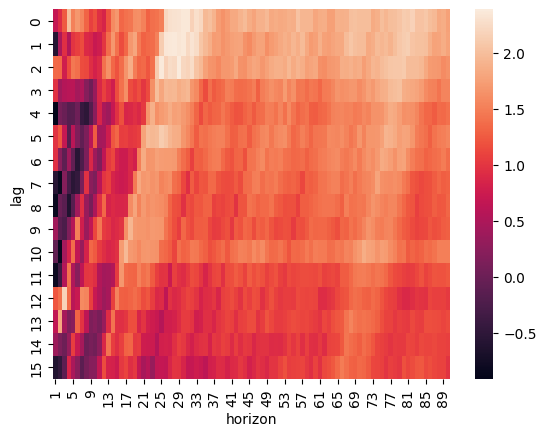

In [9]:
# ranked demean normalized portfolio based on average return for different horizons
def momentum_weights_ideal(data, hor):
    w = data.rolling(hor, min_periods=1).mean().rank(1)
    w = w.subtract(w.mean(1),0)
    w = w.divide(w.abs().sum(1),0)
    return w
    
sharpe = {}

for hor in range(1,91):
    w = momentum_weights_ideal(train_data, hor)
    for lag in range(16):
        this_w = w.shift(lag)
        gross_ret = (this_w.shift()*train_data).sum(1)
        sharpe[(hor,lag)] = gross_ret.mean()/gross_ret.std() * np.sqrt(mult)

sharpe = pd.Series(sharpe)
sharpe.index.names=['horizon','lag']
sharpe = sharpe.unstack('horizon')
sns.heatmap(sharpe)

We'll add transaction cost, assumed to be **20bps**, to check the return doesn't fade away when introducing transaction costs.  
To slow down the signal and reduce the impact of transaction cost, we optimize the weights using convex optimization.

In [10]:
class LongShortOptimizer:
    """
    Convex long–short portfolio optimizer with tracking-error minimization
    and linear transaction cost penalty.
    """

    def __init__(self, n, comm_bps=20e-4, tc_penalty=1/100., sigma_scale=1, ideal_weights=None):
        """
        Initialize the optimizer and construct the underlying CVXPY problem.

        Parameters
        ----------
        n : int
            Number of assets in the universe.

        comm_bps : float, default=20e-4
            Transaction cost per unit weight traded (in decimal form).
            Example: 20 basis points = 20e-4 = 0.002.

        tc_penalty : float, default=1/100.
            Multiplier applied to the transaction cost term.
            Controls turnover aggressiveness. Larger values reduce trading.

        sigma_scale : float, default=1
            Scaling factor applied to the covariance matrix before solving.
            Used to improve numerical conditioning of the quadratic form.

        ideal_weights : callable
            Function used to compute the time-series of ideal (signal-based)
            target weights. Expected to return a pandas DataFrame indexed
            by time with assets as columns.
        """
        
        self.n = n
        self.comm_bps = comm_bps
        self.tc_penalty = tc_penalty
        self.sigma_scale = sigma_scale
        self.ideal_weights = ideal_weights # method to calculate ideal weights

        # Parameters
        self.sigma = cvx.Parameter((n, n), PSD=True)
        self.w_ideal = cvx.Parameter(n)
        self.w_prev = cvx.Parameter(n)
        self.sign_param = cvx.Parameter(n)
        self.mask = cvx.Parameter(n)

        # Variable
        w = cvx.Variable(n)

        # Tracking error
        tracking_error = cvx.quad_form(w - self.w_ideal, self.sigma)/self.sigma_scale

        # Transaction cost
        tcost = self.tc_penalty * cvx.sum(
            cvx.abs(w - self.w_prev) * self.comm_bps
        )

        objective = cvx.Minimize(tracking_error + tcost)

        constraints = [
            cvx.sum(w) == 0,                                    # dollar neutral
            cvx.multiply(w, self.sign_param) >= 0,              # align with signal
            cvx.sum(cvx.multiply(w, self.sign_param)) == 1,     # unit signed exposure
            cvx.multiply(w, self.mask) == 0,                    # mask positions, assign no weight
        ]

        self.problem = cvx.Problem(objective, constraints)
        self.w_var = w

    def solve(self, sigma, w_ideal, w_prev, mask):
        """
        Solve the convex optimization problem for a single time step.

        Parameters
        ----------
        sigma : array-like, shape (n, n)
            Covariance matrix of asset returns. Must be positive
            semi-definite. It is internally rescaled by `sigma_scale`
            for numerical conditioning.

        w_ideal : array-like, shape (n,)
            Ideal (signal-based) portfolio weights at current time.
            These define the tracking target and sign constraints.

        w_prev : array-like, shape (n,)
            Portfolio weights from the previous time step.
            Used to compute turnover and transaction costs.

        mask : array-like, shape (n,)
            Boolean or {0,1} indicator specifying which assets must
            have zero weight. True/1 forces weight to zero.

        Returns
        -------
        ndarray, shape (n,)
            Optimized portfolio weights.
        """
        
        sigma = np.asarray(sigma * self.sigma_scale, dtype=float) # using sigma_scale to make sigma~O(1)
        w_ideal = np.asarray(w_ideal, dtype=float)
        w_prev = np.asarray(w_prev, dtype=float)

        # Update parameter values
        self.mask.value = np.asarray(mask, dtype=float)
        self.sigma.value = sigma
        self.w_ideal.value = w_ideal
        self.w_prev.value = w_prev
        self.sign_param.value = np.sign(w_ideal)
        
        self.problem.solve(solver=cvx.SCS, warm_start=True, ignore_dpp=True)

        return self.w_var.value

    def optimized_weights(self, return_data, *args):
        """
        Run rolling portfolio optimization over time.

        Parameters
        ----------
        return_data : pandas.DataFrame
            Asset return matrix of shape (T, N), indexed by time.

        *args :
            Additional arguments passed to `ideal_weights()`.

        Returns
        -------
        pandas.DataFrame
            Optimized weights over time with the same index and columns
            as `return_data`.
        """
        
        n = self.n
        w_th = self.ideal_weights(*args)

        wtg = []
        wtg.append(np.zeros(n))
        wtg.append(np.asarray(w_th.iloc[1].fillna(0)))

        for t in range(2, return_data.shape[0]):
            sigma_lw = LedoitWolf().fit(return_data.iloc[:t+1].fillna(0).values).covariance_
            w_prev = wtg[-1]
            w_ideal = w_th.iloc[t]
            mask = w_ideal.isna()  # symbols with Nan weight are forced to 0 weight
            w_ideal = w_ideal.fillna(0)
            w_opt = self.solve(sigma_lw, w_ideal, w_prev, mask)
            wtg.append(w_opt)
        return( pd.DataFrame(wtg, index = return_data.index, columns = return_data.columns) )

In [11]:
n = train_data.shape[1]
optimizer = LongShortOptimizer(n, sigma_scale=100, ideal_weights = momentum_weights_ideal)

wtgs = []
for hor in range(1,91):
    wtg = optimizer.optimized_weights(train_data, train_data, hor)
    wtg['horizon'] = hor
    wtgs.append(wtg)
    
wtgs = pd.concat(wtgs,axis=0)

In [12]:
stat = {}
tcost_bps = 20 # considering 20bps of transaction cost
for hor, wtg in wtgs.groupby('horizon'):
    wtg.drop('horizon',axis=1)
    for lag in range(16):
        this_wtg = wtg.shift(lag)
        gross_ret = (this_wtg.shift()*train_data).sum(1)
        to = (this_wtg.fillna(0) - this_wtg.shift().fillna(0)).abs().sum(1) #turnover
        net_ret = gross_ret.subtract(to*tcost_bps*1e-4,fill_value=0)
        stat[(hor,lag)] = net_ret.mean()/net_ret.std() * np.sqrt(365)

<Axes: xlabel='horizon', ylabel='lag'>

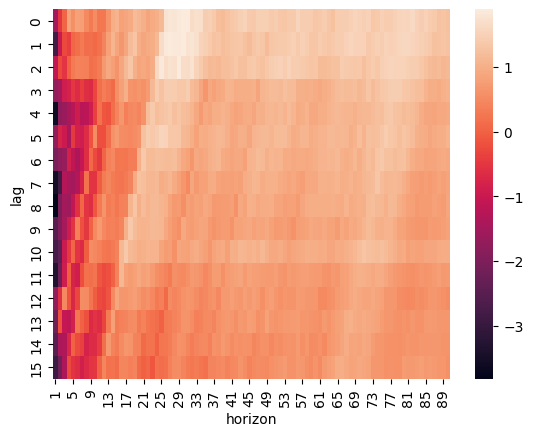

In [13]:
stat = pd.Series(stat)
stat.index.names=['horizon','lag']
stat = stat.unstack('horizon')
sns.heatmap(stat)

The sharpes are showing a flat region around **30 days averaging horizon and no lag** with the highest sharpe

Backtesting and Performance Stats
===============
Choosing 30 days averaging horizon and no lag for backtesting on the full data.  

In [14]:
mom_hor = 30
mom_lag = 0

mom_w = optimizer.optimized_weights(ret, ret, mom_hor).shift(mom_lag)

In [15]:
mom_grs_ret = (mom_w.shift()*ret).sum(1)
mom_to = (mom_w.fillna(0) - mom_w.shift().fillna(0)).abs().sum(1) #turnover
mom_net_ret = mom_grs_ret.subtract(mom_to*tcost_bps*1e-4,fill_value=0)

Performance Analysis
-------
As a comparison (benchmark) to the strategy , we use 2 portfolios:
1. buy and hold BTC
2. buy and hold equally weighted of available cryptocurrencies (All)

In [16]:
def get_stat(df, name='strat', multiplier=mult):
    stat = {}
    stat['return'] = df.mean() * multiplier
    stat['std'] = df.std() * np.sqrt(multiplier)
    stat['sharpe'] = stat['return']/stat['std']
    stat = pd.DataFrame(stat,index=[name])
    return stat

def get_yearly_stat(df, name='strat', multiplier=mult):
    stat = {}
    stat['return'] = df.resample('YE').mean() * multiplier
    stat['vol'] = df.resample('YE').std() * np.sqrt(multiplier)
    stat['sharpe'] = df.resample('YE').mean() / df.resample('YE').std() * np.sqrt(multiplier)
    stat = pd.DataFrame(stat)
    return stat

btc_ret = ret['BTCUSDT']
all_ret = ret.mean(1)

Holding period
------
The average holding period of the strategy is ~12 days.

In [17]:
# holding period in days
print(f'Average holding period of strategy: {2/mom_to.mean():.1f}')

Average holding period of strategy: 12.4


Returns
-------

<Axes: xlabel='open_time'>

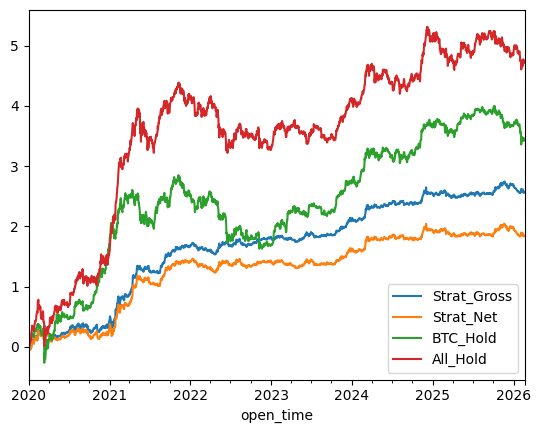

In [18]:
returns = pd.DataFrame({'Strat_Gross':mom_grs_ret, 'Strat_Net':mom_net_ret, 'BTC_Hold':btc_ret, 'All_Hold':all_ret})
returns.cumsum().plot()

The Sharpe of the strategy performs slightly better than buy and hold strategies over the whole period

In [19]:
pd.concat([ get_stat(mom_grs_ret,'Strat_Gross'),
            get_stat(mom_net_ret,'Strat_Net'),
            get_stat(btc_ret,'BTC_Hold'),
            get_stat(all_ret,'All_Hold'), ] )

,return,std,sharpe
Strat_Gross,0.417752,0.273467,1.527615
Strat_Net,0.299654,0.273923,1.093936
BTC_Hold,0.559513,0.618507,0.904619
All_Hold,0.769569,0.754439,1.020054


Looking at yearly sharpe, the buy and holds fluctuate a lot more compared to the strategy.  
(we have just a few days in 2026 in the data. still early to make a conclusion about 2026)

In [20]:
yearly_summary = pd.concat([
    get_yearly_stat(mom_grs_ret),
    get_yearly_stat(mom_net_ret),
    get_yearly_stat(btc_ret),
    get_yearly_stat(all_ret)], axis=1, keys= ['Strat_Gross', 'Strat_Net', 'BTC_Hold', 'All_Hold']).T.swaplevel(axis=0).sort_index()
yearly_summary.columns = [x.year for x in yearly_summary.columns]
yearly_summary.loc['sharpe']

,2020,2021,2022,2023,2024,2025,2026
All_Hold,1.848941,2.557298,-1.107418,1.633039,1.505232,-0.339316,-1.198477
BTC_Hold,2.254706,0.981426,-1.287920,2.349069,1.756296,0.050741,-2.594675
Strat_Gross,1.357774,3.140553,0.667347,1.503560,1.775948,0.661974,-4.102718
Strat_Net,0.948337,2.804027,0.044703,0.930639,1.337983,0.218900,-4.573764


Correlation and Beta
-----
We observe **small correlation and beta** to the benchmarks

In [21]:
print(f'Correlation to BTC buy and hold:{btc_ret.corr(mom_net_ret):.3f} and all crypto:{all_ret.corr(mom_net_ret):.3f}')
print(f'Beta to BTC buy and hold:{btc_ret.corr(mom_net_ret)*mom_net_ret.std()/btc_ret.std():.3f} and all crypto:{all_ret.corr(mom_net_ret)*mom_net_ret.std()/all_ret.std():.3f}')

Correlation to BTC buy and hold:-0.028 and all crypto:0.031
Beta to BTC buy and hold:-0.012 and all crypto:0.011


In [22]:
print('Correlation matrix:')
pd.DataFrame({'BTC_Hold':btc_ret,'All_Hold':all_ret,'Strat_Net':mom_net_ret}).corr()

Correlation matrix:


,BTC_Hold,All_Hold,Strat_Net
BTC_Hold,1.000000,0.827840,-0.028215
All_Hold,0.827840,1.000000,0.030837
Strat_Net,-0.028215,0.030837,1.000000


Alpha
---------
Due to low correlation to benchmark (BTC), we expect to see statistically significant alpha t-stats

In [23]:
def get_alpha(ret_y, ret_x):
    corr = ret_y.rolling(365,min_periods=1).corr(ret_x)
    vol_y = ret_y.rolling(365,min_periods=1).std()
    vol_x = ret_x.rolling(365,min_periods=1).std()
    beta = (corr * vol_y).divide(vol_x, 0)
    alpha = ret_y - beta.multiply(ret_x, 0)
    return alpha

def alpha_tstats(ret_y, ret_x):
    X = ret_x.copy()
    Y = ret_y.copy()
    X['const']=1
    X = X.iloc[1:]
    Y = Y.iloc[1:]
    res = sm.OLS(Y, X).fit()
    return res.tvalues

In [24]:
mom_alpha = get_alpha(mom_net_ret, btc_ret)
print(get_stat(mom_alpha,name='Alpha'),'\n')
print("t-stat:\n", alpha_tstats(mom_net_ret, ret[['BTCUSDT']]))

         return       std    sharpe
Alpha  0.291263  0.269674  1.080055 

t-stat:
 BTCUSDT   -1.335916
const      2.772454
dtype: float64


The information ratio is almost identical to the strategy Sharpe ratio. Also, alpha t-stats is showing statistically significant constant/alpha contribution (2.8).
Both results as expected, due to the strategy's low beta to the benchmark

Drawdown Amount and Duration
-------
The strategy is far more stable compared to buy and hold, showing much lower maximum drawdown and shorter drawdown duration.

In [25]:
def drawdown(px):
    return (px / px.expanding(min_periods=1).max() - 1)

def drawdown_duration(px):
    in_dd = (px.expanding(min_periods=1).max() > px)*1 # are we in drawdown period
    ddd = (in_dd.cumsum() - in_dd.cumsum().where(in_dd == 0).ffill().fillna(0))
    return ddd

mom_px = (mom_net_ret + 1).cumprod()
btc_px = (btc_ret + 1).cumprod()
all_px = (all_ret + 1).cumprod()

mom_dd = drawdown(mom_px)
btc_dd = drawdown(btc_px)
all_dd = drawdown(all_px)

print(f'Maximum drawdown of the strategy: {mom_dd.min():.2f}')
print(f'Maximum drawdown of BTC buy and hold: {btc_dd.min():.2f}')
print(f'Maximum drawdown of All buy and hold: {all_dd.min():.2f}')

Maximum drawdown of the strategy: -0.21
Maximum drawdown of BTC buy and hold: -0.77
Maximum drawdown of All buy and hold: -0.77


<Axes: title={'center': 'Drawdown Amount'}, xlabel='open_time'>

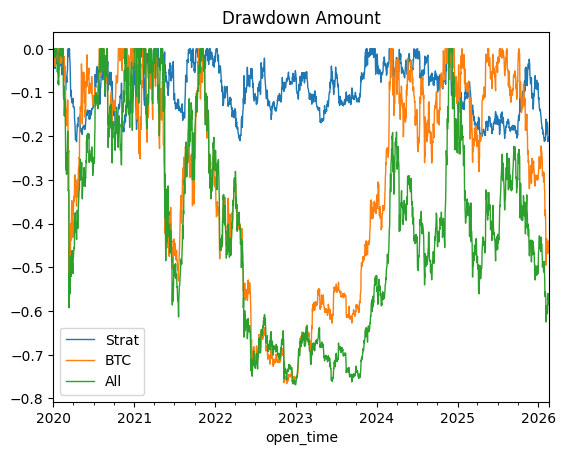

In [26]:
dd = pd.concat([mom_dd, btc_dd, all_dd], keys=['Strat', 'BTC', 'All'], axis=1)
dd.plot(linewidth=1, title='Drawdown Amount')

Maximum drawdown duration of the strategy: 676.0 days
Maximum drawdown duration of BTC buy and hold: 846.0 days
Maximum drawdown duration of All buy and hold: 1110.0 days


<Axes: title={'center': 'Drawdown Duration'}, xlabel='open_time'>

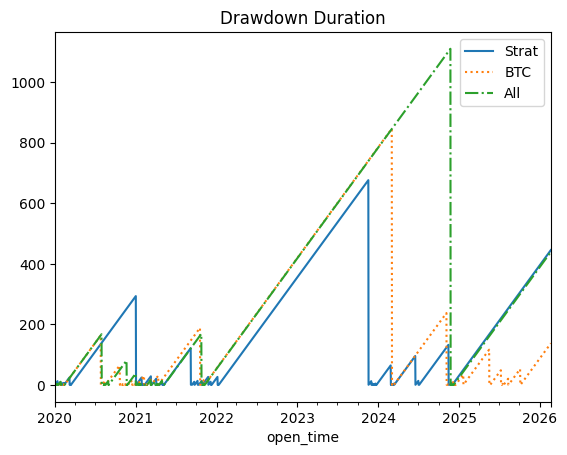

In [27]:
mom_ddd = drawdown_duration(mom_px)
btc_ddd = drawdown_duration(btc_px)
all_ddd = drawdown_duration(all_px)
ddd = pd.concat([mom_ddd, btc_ddd, all_ddd], keys=['Strat', 'BTC', 'All'], axis=1)

print(f'Maximum drawdown duration of the strategy: {mom_ddd.max()} days')
print(f'Maximum drawdown duration of BTC buy and hold: {btc_ddd.max()} days')
print(f'Maximum drawdown duration of All buy and hold: {all_ddd.max()} days')

ddd.plot(title='Drawdown Duration', style=['-', ':', '-.'])

Crossing Moving Average
==============
In this section, we consider a crossing moving average (CMA) strategy. The motivation behind the idea is that once a shorter time horizon moving average crosses a longer horizon moving average, it can signal a trend in price movement.  
Once short MA is higher than long MA, it's a signal for buy.   
Once short MA is lower than long MA, it's a signal for short.  

We normalize the difference between short MA and long MA with the volatility of prices. Lower vol signals more confidence in price direction. So, the final score is defined as $\frac{MA_{Short}-MA_{Long}}{\sigma}$.  
We employ a cross-sectional strategy, long the positions with higher score and short the positions with lower scores.

In [28]:
def cma_weights(px, long, short):
    ma_long = px.ewm(span=long).mean()
    ma_short = px.ewm(span=short).mean()
    std = px.rolling(60, min_periods=1).std()
    
    score = (ma_short - ma_long)/std
    wtg = score.rank(1)
    wtg = wtg.subtract(wtg.mean(1),0)
    wtg = wtg.divide(wtg.abs().sum(1),0)
    return wtg

In order to find best short and long horizons, we run a search through training data for a grid of 'long' and 'short' moving averages.  
The region around **~50-60 days for long horizon** and **~5 days for short horizon** shows a stable promising Sharpe.

<Axes: xlabel='long', ylabel='short'>

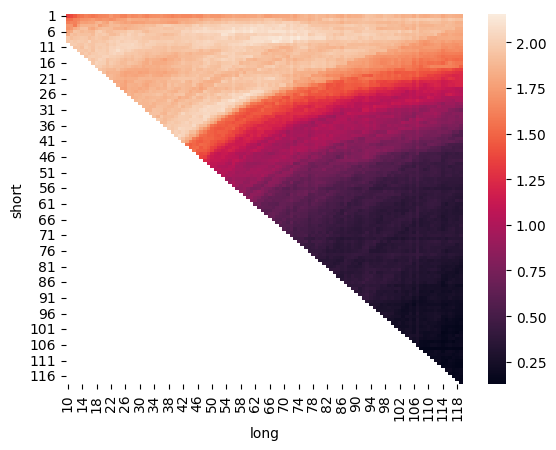

In [29]:
train_px = px[ px.index < train_date ]
train_rt = train_px.pct_change(fill_method=None)

sharpe = {}
for long in range(10,120):
    for short in range(1,long):
        wtg = cma_weights(train_px, long, short)
        gross_ret = (wtg.shift()*train_rt).sum(1)
        to = (wtg.fillna(0) - wtg.shift().fillna(0)).abs().sum(1) #turnover
        net_ret = gross_ret.subtract(to*tcost_bps*1e-4,fill_value=0)
        sharpe[(long,short)] = net_ret.mean() / net_ret.std() * np.sqrt(mult)

sharpe = pd.Series(sharpe)
sharpe.index.names = ['long','short']
sns.heatmap(sharpe.unstack('long'))

Backtesting and Performance Stats
-------
We choose 50 days for long horizon average and 5 days for short horizon. Backtesting the parameters on the full return data

In [30]:
n = px.shape[1]
optimizer = LongShortOptimizer(n, sigma_scale=100, ideal_weights = cma_weights)

span_long = 50
span_shrt = 5

cma_w = optimizer.optimized_weights(ret, px, span_long, span_shrt)
cma_grs_ret = (cma_w.shift()*ret).sum(1)
cma_to = (cma_w.fillna(0) - cma_w.shift().fillna(0)).abs().sum(1)
cma_net_ret = cma_grs_ret.subtract(cma_to*tcost_bps*1e-4,fill_value=0)

The average holding period of the strategy is **17 days**.   
The strategy shows a rather decent improvement of Sharpe compared to buy and hold strategies.

Holding period and returns
-----

In [31]:
# holding period in days
print(f'Average holding period of strategy: {2/cma_to.mean():.1f}')

Average holding period of strategy: 17.0


<Axes: xlabel='open_time'>

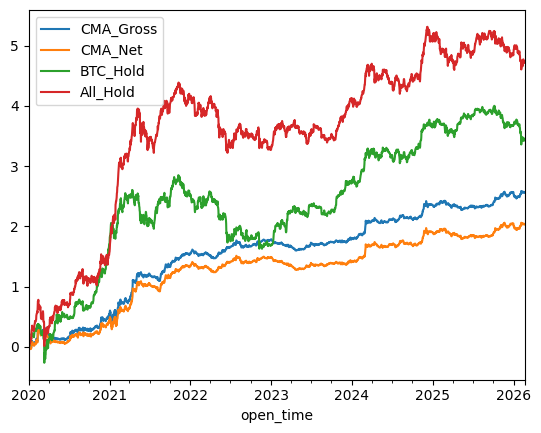

In [32]:
returns = pd.DataFrame({'CMA_Gross':cma_grs_ret, 'CMA_Net':cma_net_ret, 'BTC_Hold':btc_ret, 'All_Hold':all_ret})
returns.cumsum().plot()

In [33]:
pd.concat([ get_stat(cma_grs_ret,'CMA_Gross'),
            get_stat(cma_net_ret,'CMA_Net'),
            get_stat(btc_ret,'BTC_Hold'),
            get_stat(all_ret,'All_Hold'), ] )

,return,std,sharpe
CMA_Gross,0.416833,0.246068,1.693975
CMA_Net,0.330824,0.246335,1.342985
BTC_Hold,0.559513,0.618507,0.904619
All_Hold,0.769569,0.754439,1.020054


Below is showing yearly Sharpe stats. The strategy has negative Sharpe in 2023.

In [34]:
yearly_summary = pd.concat([
    get_yearly_stat(cma_grs_ret),
    get_yearly_stat(cma_net_ret),
    get_yearly_stat(btc_ret),
    get_yearly_stat(all_ret)], axis=1, keys= ['CMA_Gross', 'CMA_Net', 'BTC_Hold', 'All_Hold']).T.swaplevel(axis=0).sort_index()
yearly_summary.columns = [x.year for x in yearly_summary.columns]
yearly_summary.loc['sharpe']

,2020,2021,2022,2023,2024,2025,2026
All_Hold,1.848941,2.557298,-1.107418,1.633039,1.505232,-0.339316,-1.198477
BTC_Hold,2.254706,0.981426,-1.287920,2.349069,1.756296,0.050741,-2.594675
CMA_Gross,1.839088,2.659221,1.363352,0.047563,2.508624,1.195967,-0.256932
CMA_Net,1.478293,2.399743,0.858622,-0.561354,2.179687,0.812012,-0.481484


Beta and Alpha
------
As expected from a cross-sectional strategy, it shows very low correlation and beta to benchmark portfolios.

In [35]:
print(f'Correlation to BTC buy and hold:{btc_ret.corr(cma_net_ret):.3f} and all crypto:{all_ret.corr(cma_net_ret):.3f}')
print(f'Beta to BTC buy and hold:{btc_ret.corr(cma_net_ret)*cma_net_ret.std()/btc_ret.std():.3f} and all crypto:{all_ret.corr(cma_net_ret)*cma_net_ret.std()/all_ret.std():.3f}')

Correlation to BTC buy and hold:-0.040 and all crypto:-0.009
Beta to BTC buy and hold:-0.016 and all crypto:-0.003


The information ratio is almost identical to the strategy Sharpe ratio. Also, alpha t-stats is showing statistically significant constant/alpha contribution (3.4).
Both results as expected, due to the strategy's low beta to the benchmark.

In [36]:
cma_alpha = get_alpha(cma_net_ret, btc_ret)
print(get_stat(cma_alpha,name='Alpha'),'\n')
print("t-stat:\n", alpha_tstats(cma_net_ret, ret[['BTCUSDT']]))

         return       std    sharpe
Alpha  0.320166  0.241216  1.327298 

t-stat:
 BTCUSDT   -1.887977
const      3.416690
dtype: float64


Drawdown
------
Drawdown amount and duration is slightly improved compared to the previous momentum strategy.

Maximum drawdown of the strategy: -0.21


<Axes: title={'center': 'Drawdown Amount'}, xlabel='open_time'>

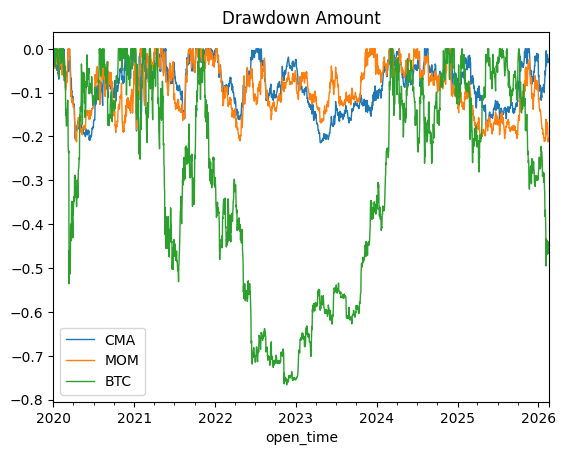

In [37]:
cma_px = (cma_net_ret + 1).cumprod()
cma_dd = drawdown(cma_px)

print(f'Maximum drawdown of the strategy: {cma_dd.min():.2f}')

dd = pd.concat([cma_dd, mom_dd, btc_dd], keys=['CMA', 'MOM', 'BTC'], axis=1)
dd.plot(linewidth=1, title='Drawdown Amount')

Maximum drawdown duration of the strategy: 581.0 days


<Axes: title={'center': 'Drawdown Duration'}, xlabel='open_time'>

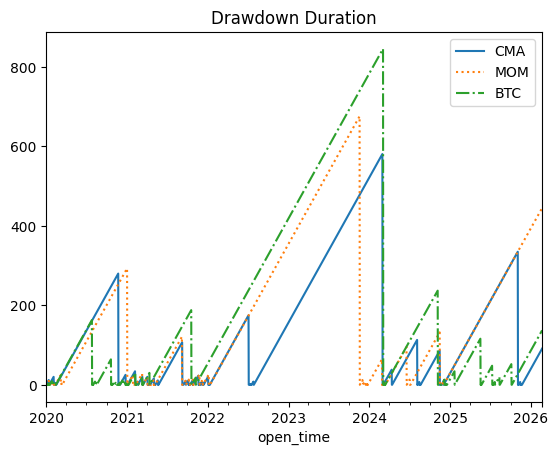

In [38]:
cma_ddd = drawdown_duration(cma_px)
ddd = pd.concat([cma_ddd, mom_ddd, btc_ddd], keys=['CMA', 'MOM', 'BTC'], axis=1)

print(f'Maximum drawdown duration of the strategy: {cma_ddd.max()} days')
ddd.plot(title='Drawdown Duration', style=['-', ':', '-.'])

Comparison and Combination
=======
In this section, we compare the two strategies developed so far, investigate their correlations and check if combining them can improve the overal performance stats. 

The strategies are showing fair amount of correlation. This is evident in the return graph below and also the comparison of yearly correlations.

<Axes: xlabel='open_time'>

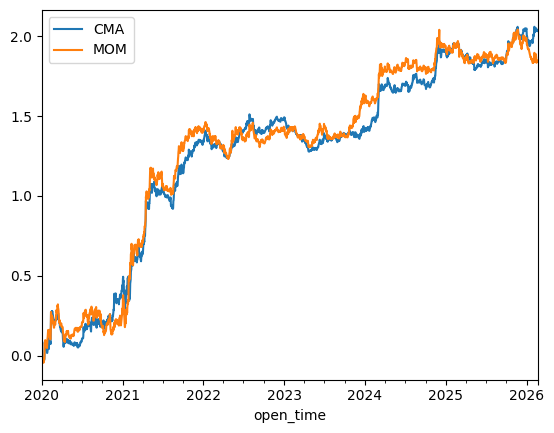

In [39]:
returns = pd.DataFrame({'CMA':cma_net_ret, 'MOM':mom_net_ret})
returns.cumsum().plot()

Yearly correlation between the two strategies

In [40]:
mom_net_ret.groupby(mom_net_ret.index.year).apply(lambda s: s.corr(cma_net_ret))

open_time
2020    0.754568
2021    0.628439
2022    0.751183
2023    0.731945
2024    0.769745
2025    0.774723
2026    0.741567
dtype: float64

Comparison of yearly Sharpes hints the possibility of getting a more stable returns by combining the two strategies.

In [41]:
yearly_summary = pd.concat([
    get_yearly_stat(mom_net_ret),
    get_yearly_stat(cma_net_ret),
    ], axis=1, keys= ['MOM', 'CMA']).T.swaplevel(axis=0).sort_index()
yearly_summary.columns = [x.year for x in yearly_summary.columns]
yearly_summary.loc['sharpe']

,2020,2021,2022,2023,2024,2025,2026
CMA,1.478293,2.399743,0.858622,-0.561354,2.179687,0.812012,-0.481484
MOM,0.948337,2.804027,0.044703,0.930639,1.337983,0.218900,-4.573764


We combine the two strategies using vol weights (higher vol -> lower contribution). We use 6 months historical return data to estimate vols.

In [42]:
cmb_ret = pd.DataFrame( {'MOM':mom_net_ret, 'CMA':cma_net_ret } )

cmb_w = [np.zeros(2), np.zeros(2)]
for t in range(2, cmb_ret.shape[0]):
    w = 1 / cmb_ret.iloc[max(0,t-180):t+1].std()
    w = w/w.sum()
    cmb_w.append(w)
cmb_w = pd.DataFrame(cmb_w, index = cmb_ret.index, columns = cmb_ret.columns).fillna(0)

In [43]:
W = mom_w.multiply(cmb_w['MOM'],0) + cma_w.multiply(cmb_w['CMA'],0)

By combining the two weights, we still have approximately a fully invested portfolio.

In [44]:
W.abs().sum(1).max()

np.float64(1.0178894894313042)

In [45]:
cmb_grs_ret = (W.shift()*ret).sum(1)
cmb_to = (W.fillna(0) - W.shift().fillna(0)).abs().sum(1) #turnover
cmb_net_ret = cmb_grs_ret.subtract(cmb_to*tcost_bps*1e-4,fill_value=0)

Holding period and returns 
------

In [46]:
print(f'Average holding period of strategy: {2/cmb_to.mean():.1f}')

Average holding period of strategy: 15.7


On the margin, combining the two strategies has dampended the fluctuations. Drawdown amount and duration slightly improved.  
The combined version is denoted by **CMB**.

In [47]:
get_stat(cmb_net_ret)

,return,std,sharpe
strat,0.32913,0.239463,1.374449


In [48]:
yearly_summary = pd.concat([
    get_yearly_stat(mom_net_ret),
    get_yearly_stat(cma_net_ret),
    get_yearly_stat(cmb_net_ret),
    ], axis=1, keys= ['MOM', 'CMA', 'CMB']).T.swaplevel(axis=0)
yearly_summary.columns = [x.year for x in yearly_summary.columns]
yearly_summary.loc['sharpe']

,2020,2021,2022,2023,2024,2025,2026
MOM,0.948337,2.804027,0.044703,0.930639,1.337983,0.218900,-4.573764
CMA,1.478293,2.399743,0.858622,-0.561354,2.179687,0.812012,-0.481484
CMB,1.424037,2.917302,0.534674,0.269839,1.914556,0.569332,-2.466450


Alpha
----
Alpha t-stats is showing statistically significant constant/alpha contribution (3.5)

In [49]:
cmb_alpha = get_alpha(cmb_net_ret, btc_ret)
print(get_stat(cmb_alpha,name='Alpha'),'\n')
print("t-stat:\n", alpha_tstats(cmb_net_ret, ret[['BTCUSDT']]))

         return       std    sharpe
Alpha  0.315737  0.234609  1.345801 

t-stat:
 BTCUSDT   -1.648770
const      3.482686
dtype: float64


Drawdown
------

In [50]:
cmb_px = (1+cmb_net_ret).cumprod()
cmb_dd = drawdown(cmb_px)
print(f'Maximum drawdown: {cmb_dd.min():.2f}')

Maximum drawdown: -0.20


Maximum drawdown duration of the strategy: 505.0 days


<Axes: title={'center': 'Drawdown Duration'}, xlabel='open_time'>

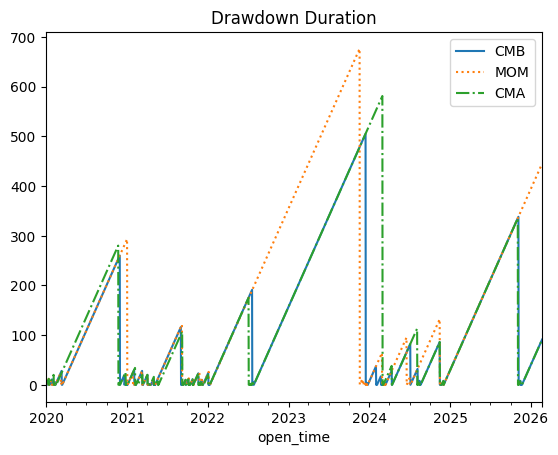

In [51]:
cmb_ddd = drawdown_duration(cmb_px)
ddd = pd.concat([cmb_ddd, mom_ddd, cma_ddd], keys=['CMB', 'MOM', 'CMA'], axis=1)

print(f'Maximum drawdown duration of the strategy: {cmb_ddd.max()} days')
ddd.plot(title='Drawdown Duration', style=['-', ':', '-.'])
